# Challenge 1 - Step 1: Access and process

> "You receive a dataset containing different aging conditions of a 102 Ah LFP cell. This dataset is the target data, where the final validation and reporting needs to be done from your side. Get familiar with the dataset. The data contains some challenges that need to be handled, like missing data or outliers."

This notebook covers **only** step 1 of the challenge (access + process + get familiar), using the exact same `Cell` objects the framework hands to `my_model`. No modeling is done here.

Goals:
1. Load the released `dataset/` the same way `run_model.py --model train` does (via `framework.data.load_cells`).
2. Understand the SOH label definition and check its coverage/quality per cell.
3. Inspect the raw time-series signals for missing sensors, out-of-window values, sampling irregularities and non-standard step types.
4. Visualize the SOH-vs-cycle trajectories and one representative raw cycle to understand the CC-CV protocol.
5. Summarize the concrete data challenges found, to inform the pre-training / fine-tuning steps (2-4) that come later.

In [1]:
import gc
import glob
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# repo root = parent of this notebooks/ folder
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "framework").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from framework.data import NOMINAL_AH, load_cells  # noqa: E402  (DO NOT EDIT framework/)

DATA_DIR = PROJECT_ROOT / "dataset"
print("project root:", PROJECT_ROOT)
print("data dir:", DATA_DIR, "exists:", DATA_DIR.exists())

project root: c:\Users\user\OneDrive - Institut National Polytechnique Félix HOUPHOUËT-BOIGNY - INP-HB\Bureau\agorize\WattPowerAI_Challenge1
data dir: c:\Users\user\OneDrive - Institut National Polytechnique Félix HOUPHOUËT-BOIGNY - INP-HB\Bureau\agorize\WattPowerAI_Challenge1\dataset exists: True


In [2]:
cells = load_cells(str(DATA_DIR))
print(f"{len(cells)} cells loaded")
cells

  loaded Cell(102Ah_25degC_0p5C_cell3, T=25 degC, C=0.5, 988 labeled cycles)
  loaded Cell(102Ah_25degC_1C_cell3, T=25 degC, C=1.0, 4155 labeled cycles)
  loaded Cell(102Ah_35degC_1C_cell1, T=35 degC, C=1.0, 5354 labeled cycles)
  loaded Cell(102Ah_45degC_0p5C_cell3, T=45 degC, C=0.5, 4296 labeled cycles)
  loaded Cell(102Ah_45degC_1C_cell1, T=45 degC, C=1.0, 2323 labeled cycles)
  loaded Cell(102Ah_55degC_1C_cell3, T=55 degC, C=1.0, 2176 labeled cycles)
6 cells loaded


[Cell(102Ah_25degC_0p5C_cell3, T=25 degC, C=0.5, 988 labeled cycles),
 Cell(102Ah_25degC_1C_cell3, T=25 degC, C=1.0, 4155 labeled cycles),
 Cell(102Ah_35degC_1C_cell1, T=35 degC, C=1.0, 5354 labeled cycles),
 Cell(102Ah_45degC_0p5C_cell3, T=45 degC, C=0.5, 4296 labeled cycles),
 Cell(102Ah_45degC_1C_cell1, T=45 degC, C=1.0, 2323 labeled cycles),
 Cell(102Ah_55degC_1C_cell3, T=55 degC, C=1.0, 2176 labeled cycles)]

## 1. Fleet overview

One row per released cell: operating condition, cycle count, SOH label coverage, and whether the cell was cycled deep enough to reach the 70% SOH target the challenge asks us to predict down to.

In [3]:
def cell_overview_row(c):
    soh = c.soh
    labeled = soh.dropna(subset=["soh_percent"])
    n_parts = len(glob.glob(str(Path(c.folder) / f"{c.cell_id}_time_series_part*.csv")))
    return {
        "cell_id": c.cell_id,
        "temperature_degC": c.temperature_degC,
        "c_rate": c.c_rate,
        "n_raw_parts": n_parts,
        "n_cycles_total": int(soh["cycle_number"].max()),
        "n_cycles_labeled": len(labeled),
        "n_cycles_unlabeled": int(soh["soh_percent"].isna().sum()),
        "soh_first_pct": round(labeled["soh_percent"].iloc[0], 2) if len(labeled) else np.nan,
        "soh_last_pct": round(labeled["soh_percent"].iloc[-1], 2) if len(labeled) else np.nan,
        "soh_min_pct": round(labeled["soh_percent"].min(), 2) if len(labeled) else np.nan,
        "reaches_70pct": bool((labeled["soh_percent"] <= 70).any()),
    }

overview = (pd.DataFrame([cell_overview_row(c) for c in cells])
            .sort_values(["temperature_degC", "c_rate"])
            .reset_index(drop=True))
overview

,cell_id,temperature_degC,c_rate,n_raw_parts,n_cycles_total,n_cycles_labeled,n_cycles_unlabeled,soh_first_pct,soh_last_pct,soh_min_pct,reaches_70pct
0,102Ah_25degC_0p5C_cell3,25,0.5,6,1375,988,0,102.14,93.10,93.10,False
1,102Ah_25degC_1C_cell3,25,1.0,14,5307,4155,1,102.53,66.25,66.25,True
2,102Ah_35degC_1C_cell1,35,1.0,13,5356,5354,0,102.14,72.58,54.44,True
3,102Ah_45degC_0p5C_cell3,45,0.5,20,4501,4296,3,103.02,58.72,42.75,True
4,102Ah_45degC_1C_cell1,45,1.0,6,2397,2323,1,102.61,84.78,84.78,False
5,102Ah_55degC_1C_cell3,55,1.0,6,2415,2176,0,102.84,65.70,65.70,True


The full test matrix spans **25-55 degC x 0.5-1.0 C** but the released dataset only covers a handful of combinations (one cell per condition, no replicate at most conditions) - the six "unseen conditions" and the withheld sibling cells mentioned in the brief are exactly the gaps in this table. Note also whether each cell was actually cycled down to 70% SOH: cells that stop earlier only give partial supervision for the end-of-life / knee region.

## 2. SOH-vs-cycle trajectories

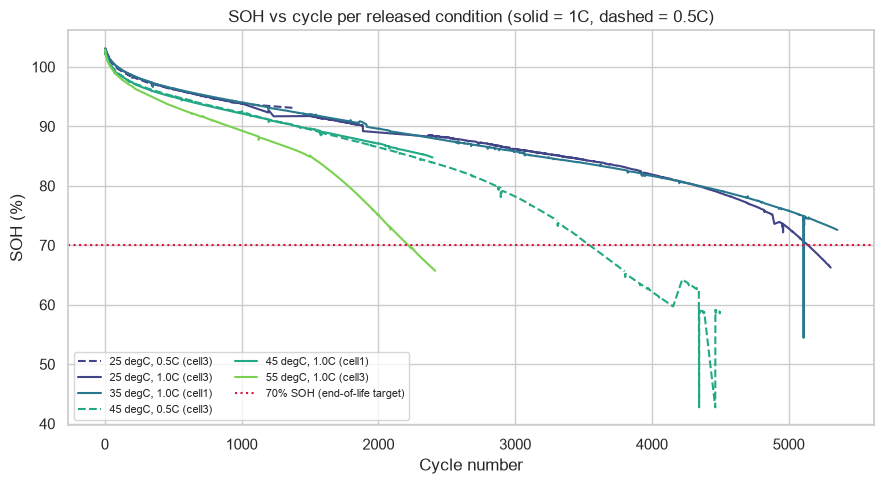

In [4]:
temps = sorted(overview["temperature_degC"].unique())
temp_colors = dict(zip(temps, sns.color_palette("viridis", n_colors=len(temps))))

fig, ax = plt.subplots(figsize=(9, 5))
for c in cells:
    style = "-" if c.c_rate == 1.0 else "--"
    ax.plot(c.soh["cycle_number"], c.soh["soh_percent"], style,
            color=temp_colors[c.temperature_degC], linewidth=1.5,
            label=f"{c.temperature_degC} degC, {c.c_rate}C ({c.cell_id.split('_')[-1]})")

ax.axhline(70, color="crimson", linestyle=":", linewidth=1.5, label="70% SOH (end-of-life target)")
ax.set_xlabel("Cycle number")
ax.set_ylabel("SOH (%)")
ax.set_title("SOH vs cycle per released condition (solid = 1C, dashed = 0.5C)")
ax.legend(fontsize=8, ncol=2, loc="lower left")
plt.tight_layout()
plt.show()

## 3. SOH label coverage: missing data & outliers

`framework.data._derive_soh` already flags two kinds of cycles as unlabeled (`soh_percent = NaN`):
- **implausible** discharge capacity (> 1.15 x nominal, or negative),
- **partial/aborted** cycles (discharge capacity far below the local rolling median).

    "These gaps are exactly the \"missing data / outliers\" the brief warns about. We visualize where they fall on each cell's cycle axis - a model that na<>ively interpolates over these gaps without knowing they are label-quality artifacts (not real SOH excursions) would learn the wrong fade shape.\n",
    "\n",
    "Note the scatter below only marks cycles that produced *some* SOH row (green = labeled, red = flagged NaN). It does **not** show a third, larger issue visible in the SOH-vs-cycle plot above: entire cycle ranges with no `cc_discharge` step at all (e.g. `102Ah_25degC_0p5C_cell3` around cycles 1000-1370, `102Ah_25degC_1C_cell3` around 1000-1300 and 1900-2300, `102Ah_55degC_1C_cell3` around 200-450) - those cycles are silently absent from `cell.soh`, and the sharp dip-then-recover visible on `102Ah_45degC_0p5C_cell3` around cycle 4300 survives the implausible/partial filters entirely."

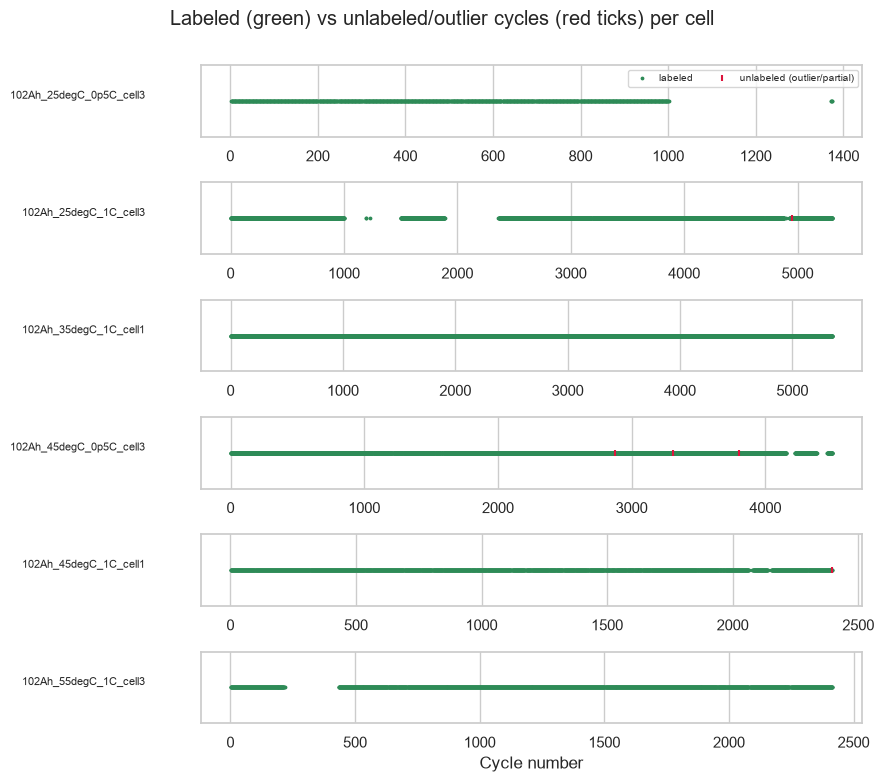

,cell_id,n_cycles_total,n_cycles_labeled,n_cycles_unlabeled,pct_unlabeled
0,102Ah_25degC_0p5C_cell3,1375,988,0,0.00
1,102Ah_25degC_1C_cell3,5307,4155,1,0.02
2,102Ah_35degC_1C_cell1,5356,5354,0,0.00
3,102Ah_45degC_0p5C_cell3,4501,4296,3,0.07
4,102Ah_45degC_1C_cell1,2397,2323,1,0.04
5,102Ah_55degC_1C_cell3,2415,2176,0,0.00


In [5]:
fig, axes = plt.subplots(len(cells), 1, figsize=(9, 1.3 * len(cells)), sharex=False)
for ax, c in zip(axes, cells):
    nan_mask = c.soh["soh_percent"].isna()
    ax.scatter(c.soh.loc[~nan_mask, "cycle_number"], np.zeros((~nan_mask).sum()),
               s=3, color="seagreen", label="labeled")
    ax.scatter(c.soh.loc[nan_mask, "cycle_number"], np.zeros(nan_mask.sum()),
               s=25, color="crimson", marker="|", label="unlabeled (outlier/partial)")
    ax.set_yticks([])
    ax.set_ylabel(c.cell_id, rotation=0, ha="right", fontsize=8, labelpad=40)
axes[0].legend(loc="upper right", fontsize=7, ncol=2)
axes[-1].set_xlabel("Cycle number")
fig.suptitle("Labeled (green) vs unlabeled/outlier cycles (red ticks) per cell", y=1.0)
plt.tight_layout()
plt.show()

overview[["cell_id", "n_cycles_total", "n_cycles_labeled", "n_cycles_unlabeled"]].assign(
    pct_unlabeled=lambda d: (d["n_cycles_unlabeled"] / d["n_cycles_total"] * 100).round(2)
)

## 4. Raw signal-level data quality

Now go one level down, into `cell.time_series()`, to check the challenges called out in the brief: missing temperature sensor readings, non-standard step types (e.g. verification/`logic_test` segments), out-of-protocol voltages, sampling gaps, and duplicate rows. Cells are processed **one at a time** and released (`del` + `gc.collect()`) to keep peak memory bounded - the full dataset is ~560 MB of CSV, and the largest single cell is ~1400 raw parts worth of ~180 MB.

In [6]:
VOLTAGE_WINDOW = (2.5, 3.65)  # documented protocol window
EXPECTED_SAMPLE_S = 30.0      # documented sampling interval

diagnostics = []
for c in cells:
    ts = c.time_series()

    step_counts = ts["step_type"].value_counts(dropna=False)
    step_pct = (step_counts / len(ts) * 100).round(2)

    abs_time = pd.to_datetime(ts["absolute_time"])
    dt = abs_time.sort_values().diff().dt.total_seconds()
    dt_pos = dt[dt > 0]

    v_out = ((ts["voltage_V"] < VOLTAGE_WINDOW[0]) | (ts["voltage_V"] > VOLTAGE_WINDOW[1])).mean() * 100
    n_dupes = ts.duplicated(subset=["cycle_number", "step_type", "time_in_cycle_s"]).sum()

    diagnostics.append({
        "cell_id": c.cell_id,
        "n_rows": len(ts),
        "step_types_present": ", ".join(step_counts.index.astype(str)),
        "pct_missing_temperature": round(ts["temperature_C"].isna().mean() * 100, 2),
        "pct_voltage_out_of_window": round(v_out, 3),
        "n_duplicate_rows": int(n_dupes),
        "median_sample_interval_s": round(dt_pos.median(), 1) if len(dt_pos) else np.nan,
        "pct_gaps_gt_2x_expected": round((dt_pos > 2 * EXPECTED_SAMPLE_S).mean() * 100, 2) if len(dt_pos) else np.nan,
    })

    del ts, abs_time, dt, dt_pos
    gc.collect()

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df

,cell_id,n_rows,step_types_present,pct_missing_temperature,pct_voltage_out_of_window,n_duplicate_rows,median_sample_interval_s,pct_gaps_gt_2x_expected
0,102Ah_25degC_0p5C_cell3,595012,"cccv_charge, cc_discharge, rest",16.42,0.097,30,30.0,0.00
1,102Ah_25degC_1C_cell3,1830763,"rest, cc_discharge, cccv_charge, cc_charge",0.00,0.036,97505,30.0,0.01
2,102Ah_35degC_1C_cell1,1857025,"rest, cccv_charge, cc_discharge, cc_charge",19.79,3.893,139,30.0,0.00
3,102Ah_45degC_0p5C_cell3,2768377,"cc_discharge, cccv_charge, rest, cc_charge",0.01,0.389,171,30.0,0.00
4,102Ah_45degC_1C_cell1,820940,"rest, cccv_charge, cc_discharge",0.00,2.139,58,30.0,0.01
5,102Ah_55degC_1C_cell3,729740,"rest, cccv_charge, cc_discharge",0.03,0.015,75,30.0,0.00


## 5. Anatomy of one cycle (CC-CV protocol)

Documented protocol: 30 min rest -> CC-CV charge to 3.649 V -> 30 min rest -> CC discharge to 2.5 V, sampled every 30 s. We plot one mid-life cycle of a single cell to confirm this and to see what each `step_type` looks like in voltage/current/temperature.

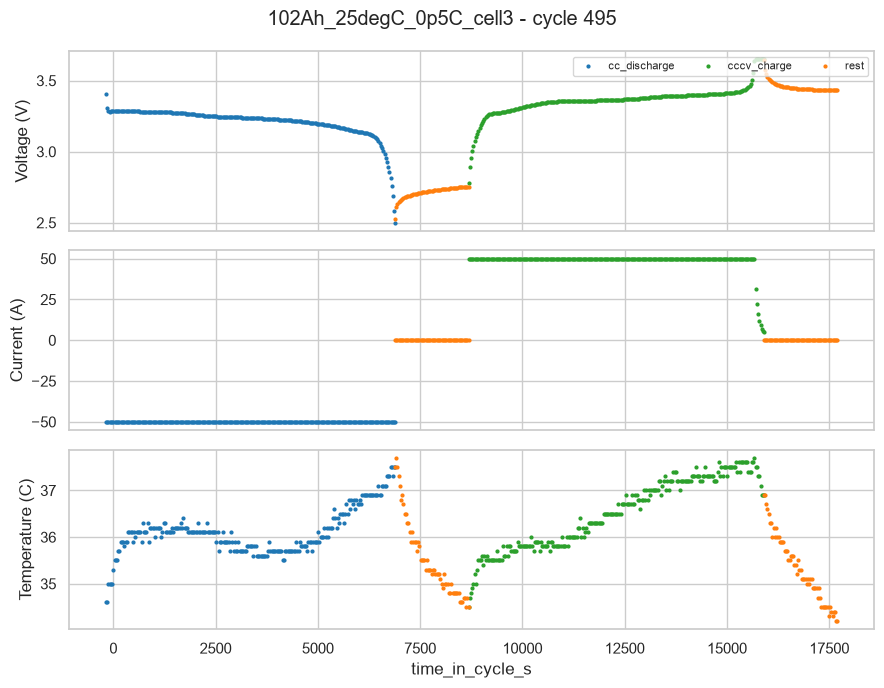

39

In [7]:
sample_cell = cells[0]
ts = sample_cell.time_series()
mid_cycle = int(ts["cycle_number"].median())
cyc = ts[ts["cycle_number"] == mid_cycle].sort_values("time_in_cycle_s")

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
step_palette = dict(zip(cyc["step_type"].unique(), sns.color_palette("tab10")))
for step, g in cyc.groupby("step_type"):
    axes[0].scatter(g["time_in_cycle_s"], g["voltage_V"], s=4, color=step_palette[step], label=step)
    axes[1].scatter(g["time_in_cycle_s"], g["current_A"], s=4, color=step_palette[step])
    axes[2].scatter(g["time_in_cycle_s"], g["temperature_C"], s=4, color=step_palette[step])

axes[0].set_ylabel("Voltage (V)")
axes[1].set_ylabel("Current (A)")
axes[2].set_ylabel("Temperature (C)")
axes[2].set_xlabel("time_in_cycle_s")
axes[0].legend(fontsize=8, ncol=4, loc="upper right")
fig.suptitle(f"{sample_cell.cell_id} - cycle {mid_cycle}")
plt.tight_layout()
plt.show()

del ts, cyc
gc.collect()

## 6. Fade rate & knee-point indication

The challenge specifically asks to predict through the **knee point**. As a purely descriptive check (no modeling), we look at the per-cycle SOH derivative to see where fade accelerates for the cells that were cycled long enough to show it.

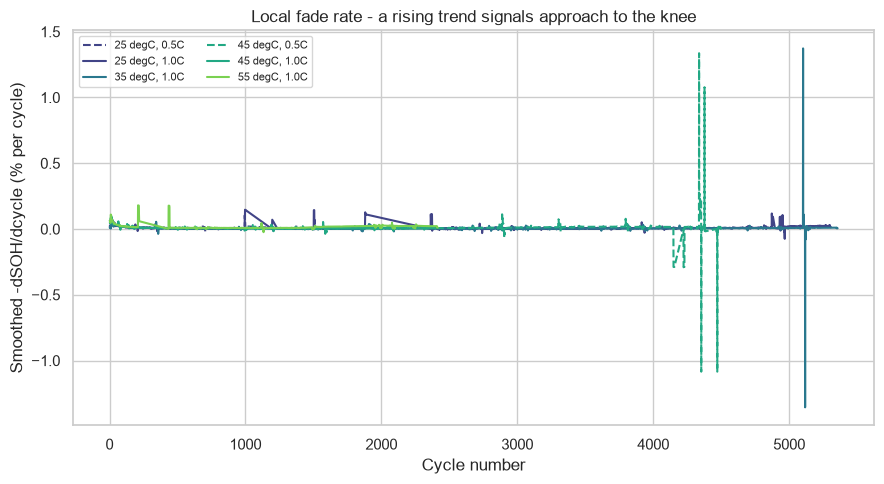

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for c in cells:
    labeled = c.soh.dropna(subset=["soh_percent"]).sort_values("cycle_number")
    if len(labeled) < 20:
        continue
    smooth = labeled["soh_percent"].rolling(15, min_periods=5, center=True).mean()
    fade_rate = -smooth.diff() / labeled["cycle_number"].diff()
    style = "-" if c.c_rate == 1.0 else "--"
    ax.plot(labeled["cycle_number"], fade_rate, style, color=temp_colors[c.temperature_degC],
            label=f"{c.temperature_degC} degC, {c.c_rate}C")

ax.set_xlabel("Cycle number")
ax.set_ylabel("Smoothed -dSOH/dcycle (% per cycle)")
ax.set_title("Local fade rate - a rising trend signals approach to the knee")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

The sharp spikes (e.g. `45 degC, 0.5C` around cycle 4300, `25 degC, 1C` around cycle 5100) line up exactly with the coverage gaps and the outlier dip identified in section 3 - they are artifacts of dividing by a large cycle-number gap or of a single bad SOH reading, **not** real accelerated fade. Any knee-detection logic built on top of this must first close/exclude those gaps (e.g. interpolate only within contiguous labeled runs) rather than differencing across them directly.

## 7. Summary: data challenges found (step 1 deliverable)

- **Sparse condition coverage.** Only 6 (temperature, C-rate) combinations are released, one cell each, out of the full 25-55 degC x 0.5-1.0 C matrix - most of the matrix, plus all sibling/replicate cells, is hidden and must be extrapolated to.
    "- **Whole-range coverage gaps.** Several cells have stretches of cycles with no `cc_discharge` step at all, so they never even enter `cell.soh` (e.g. `102Ah_25degC_0p5C_cell3` ~1000-1370, `102Ah_25degC_1C_cell3` ~1000-1300 and ~1900-2300, `102Ah_55degC_1C_cell3` ~200-450 - visible as broken lines in section 1's plot and as blank stretches in section 3's coverage chart). Naively differencing/interpolating across these gaps (section 6) produces spurious fade-rate spikes that look like knees but aren't.\n",
    "- **Unlabeled/outlier cycles the filters do catch.** A small number of cycles per cell are flagged `NaN` for implausible (> 1.15x nominal) or partial/aborted discharge capacity (see section 3) - these must stay excluded from training rather than imputed as fade.\n",
    "- **Outliers the filters miss.** `102Ah_45degC_0p5C_cell3` shows a sharp SOH dip-and-partial-recovery around cycle 4300 (from ~59% down to ~43% and back) that is *not* caught by the implausible/partial heuristics - a reminder that the provided `soh_percent` cleaning is not exhaustive and extra outlier handling may be needed.\n",
    "- **Missing temperature sensor data.** `temperature_C` availability varies by cell (see `pct_missing_temperature` above, up to ~20% missing) - any signal-based feature relying on temperature needs a per-cell fallback (e.g. nominal chamber temperature) or must tolerate `NaN`.\n",
- **Uneven cycling depth.** Not every released cell was cycled down to 70% SOH (`reaches_70pct` in section 1) - end-of-life / knee behaviour is only directly observed for a subset of conditions.
- **Large, chunked raw files.** Time series are split into <=100 MB parts per cell (up to ~1400 rows/cycle x thousands of cycles); loading all cells' full time series at once is memory-heavy, so processing is done per-cell in this notebook (and should be in `fit()` too, e.g. via streaming aggregation or cached derived features).
- **Protocol markers.** No `logic_test`/`other` step types were found in the released cells (`step_types_present` above only lists `rest`, `cccv_charge`, `cc_charge`, `cc_discharge`) - this should be re-checked whenever new cells are added, since the brief explicitly reserves that category for verification-protocol segments to exclude.
- **Sampling/voltage sanity.** Sampling interval and voltage-window checks above (`median_sample_interval_s`, `pct_gaps_gt_2x_expected`, `pct_voltage_out_of_window`) confirm whether the documented 30 s / 2.5-3.65 V protocol holds throughout, or whether specific cells need extra cleaning before being used as pre-training/fine-tuning signal.

These findings define the cleaning rules that step 2 (pre-training on open data) and step 3 (fine-tuning on this target set) must apply consistently - no modeling decision is made in this notebook.